<a href="https://sigmoidal.ai">
  <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="300">
</a>

# Regressão Linear e Aprendizado Supervisionado

Notebook complementar do artigo publicado no [blog Sigmoidal](https://sigmoidal.ai).

Primeiro da série **Matemática para Machine Learning**. Aqui construímos o modelo
$f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b$ a partir de vetores e produto
escalar, com a notação do curso de Andrew Ng. O treinamento (função de custo e gradient
descent) é o tema do próximo notebook.

## Importações e configurações

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

np.random.seed(42)

## 1. Dados como vetores

Cada exemplo é um vetor de features; o dataset inteiro é uma matriz $\mathbf{X}$ de
dimensão $m \times d$ ($m$ exemplos, $d$ features). Usamos um dataset de imóveis com
três features: área ($m^2$), número de quartos e idade (anos).

In [2]:
# 5 imoveis, 3 features: [area(m2), quartos, idade(anos)]
X = np.array([
    [ 80, 2,  5],
    [120, 3, 10],
    [ 60, 1,  2],
    [200, 4, 15],
    [ 95, 2,  8],
], dtype=float)

print("X tem dimensao", X.shape, "->", X.shape[0], "exemplos,", X.shape[1], "features")
print("Primeiro exemplo, x^(1) =", X[0])

X tem dimensao (5, 3) -> 5 exemplos, 3 features
Primeiro exemplo, x^(1) = [80.  2.  5.]


## 2. Produto escalar e vetorização

O **produto escalar** entre dois vetores $\mathbf{u}, \mathbf{v} \in \mathbb{R}^d$ é

$$\mathbf{u} \cdot \mathbf{v} = \sum_{j=1}^{d} u_j v_j.$$

O resultado é um único número. Em NumPy, o operador `@` calcula esse produto. Comparamos
a versão com laços explícitos contra a versão vetorizada para medir a diferença de desempenho.

In [3]:
def soma_ponderada_loop(X, w):
    """Soma ponderada das features com laços em Python puro."""
    N, d = X.shape
    saida = np.zeros(N)
    for i in range(N):
        for j in range(d):
            saida[i] += X[i, j] * w[j]
    return saida


def soma_ponderada_numpy(X, w):
    """Mesma operação, com o produto matricial do NumPy."""
    return X @ w


# As duas funcoes devem produzir o mesmo resultado
w_demo = np.array([3.0, 15.0, -1.5])
print("Loop  :", soma_ponderada_loop(X, w_demo))
print("NumPy :", soma_ponderada_numpy(X, w_demo))

Loop  : [262.5 390.  192.  637.5 303. ]
NumPy : [262.5 390.  192.  637.5 303. ]


In [4]:
# Mesmo calculo em escala: N = 100.000 exemplos, d = 10 features
N, d = 100_000, 10
X_grande = np.random.randn(N, d)
w_grande = np.random.randn(d)

inicio = time.perf_counter()
soma_ponderada_loop(X_grande, w_grande)
tempo_loop = time.perf_counter() - inicio

inicio = time.perf_counter()
soma_ponderada_numpy(X_grande, w_grande)
tempo_numpy = time.perf_counter() - inicio

print(f"Loop  : {tempo_loop*1000:.1f} ms")
print(f"NumPy : {tempo_numpy*1000:.2f} ms")
print(f"NumPy e cerca de {tempo_loop/tempo_numpy:.0f}x mais rapido")

Loop  : 428.5 ms
NumPy : 2.00 ms
NumPy e cerca de 214x mais rapido


## 3. O modelo de regressão linear

Com $d$ features, o modelo prevê

$$f_{\mathbf{w},b}(\mathbf{x}) = w_1 x_1 + w_2 x_2 + \cdots + w_d x_d + b
= \mathbf{w} \cdot \mathbf{x} + b.$$

O vetor $\mathbf{w}$ contém os pesos das features e o escalar $b$ é o termo de viés
(*bias*). Implementamos a predição primeiro para um único exemplo e depois para o dataset
inteiro de uma vez.

In [5]:
def prever_um(x, w, b):
    """Predicao do modelo para um unico exemplo x."""
    return np.dot(w, x) + b


# Pesos e vies escolhidos (precos em milhares de R$)
w = np.array([3.0, 15.0, -1.5])
b = 50.0

x1 = X[0]
print("x^(1)            =", x1)
print("w . x^(1)        =", np.dot(w, x1))
print("f(x^(1)) = w.x+b =", prever_um(x1, w, b))

x^(1)            = [80.  2.  5.]
w . x^(1)        = 262.5
f(x^(1)) = w.x+b = 312.5


In [6]:
def prever(X, w, b):
    """Predicao vetorizada para todos os exemplos de X."""
    return X @ w + b


y_hat = prever(X, w, b)
for i, (xi, pred) in enumerate(zip(X, y_hat)):
    print(f"Imovel {i+1}: area={xi[0]:.0f}m2, quartos={xi[1]:.0f}, idade={xi[2]:.0f}a -> R$ {pred:.0f} mil")

Imovel 1: area=80m2, quartos=2, idade=5a -> R$ 312 mil
Imovel 2: area=120m2, quartos=3, idade=10a -> R$ 440 mil
Imovel 3: area=60m2, quartos=1, idade=2a -> R$ 242 mil
Imovel 4: area=200m2, quartos=4, idade=15a -> R$ 688 mil
Imovel 5: area=95m2, quartos=2, idade=8a -> R$ 353 mil


## 4. Visualizando o modelo com uma feature

Com uma única feature, $f_{w,b}(x) = w x + b$ é uma reta: $w$ é a inclinação e $b$ é o
intercepto. Geramos dados sintéticos em torno de $y = 2x + 1$ e sobrepomos a reta do
modelo. Os pesos aqui foram **escolhidos**, não treinados; encontrar os melhores $w$ e $b$
é o tema do próximo notebook.

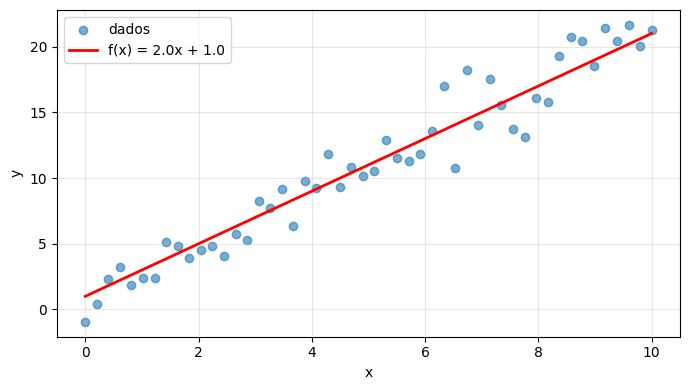

In [7]:
# Dados sinteticos: y ~ 2x + 1 + ruido
x = np.linspace(0, 10, 50)
y = 2 * x + 1 + np.random.randn(50) * 1.5

w1, b1 = 2.0, 1.0
y_reta = w1 * x + b1

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, alpha=0.6, label="dados")
ax.plot(x, y_reta, "r-", linewidth=2, label=f"f(x) = {w1}x + {b1}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.tight_layout()
plt.show()

## Recapitulando

- Exemplos são **vetores**; o dataset é uma **matriz**.
- O **produto escalar** combina pesos e features em um único número, e a forma vetorizada
  é ordens de grandeza mais rápida que laços.
- O modelo de regressão linear é $f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b$,
  válido para 1 ou milhares de features.

No próximo notebook definimos a **função de custo (MSE)** e o **gradient descent** para
encontrar os parâmetros $\mathbf{w}$ e $b$ que ajustam o modelo aos dados.